In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os

In [5]:

df = pd.read_csv(r"C:\Users\borse\Downloads\archive\train.csv")


In [3]:
print("Shape:", df.shape)

Shape: (9800, 18)


In [4]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [6]:
print(df.head())

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
1       2  CA-2017-152156  08/11/2017  11/11/2017    Second Class    CG-12520   
2       3  CA-2017-138688  12/06/2017  16/06/2017    Second Class    DV-13045   
3       4  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   
4       5  US-2016-108966  11/10/2016  18/10/2016  Standard Class    SO-20335   

     Customer Name    Segment        Country             City       State  \
0      Claire Gute   Consumer  United States        Henderson    Kentucky   
1      Claire Gute   Consumer  United States        Henderson    Kentucky   
2  Darrin Van Huff  Corporate  United States      Los Angeles  California   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale     Florida   

   Postal Code Region       Product ID         Cat

*******Data Cleaning*******

In [7]:
df.columns = df.columns.str.strip()

In [8]:
print("\nMissing values:\n", df.isnull().sum())


Missing values:
 Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64


In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"], format="%d/%m/%Y", errors="coerce")

In [11]:
df["Ship Date"] = pd.to_datetime(df["Ship Date"], format="%d/%m/%Y", errors="coerce")

In [12]:
df.dropna(subset=["Order Date", "Ship Date"], inplace=True)

In [13]:
text_cols = df.select_dtypes(include=["object", "str"]).columns
for col in text_cols:
    df[col] = df[col].astype(str).str.strip()
 

*****Feature Enginerring*****

In [14]:
df["Order Year"] = df["Order Date"].dt.year

In [15]:
df["Order Month"] = df["Order Date"].dt.month

In [16]:
df["Order Month Name"] = df["Order Date"].dt.strftime("%b")

In [17]:
df["Delivery Time (Days)"] = (df["Ship Date"] - df["Order Date"]).dt.days

******EXPLORATORY DATA ANALYSIS******

In [18]:
sns.set_style("whitegrid")

In [19]:
monthly_sales = df.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"].sum().reset_index()

In [20]:
plt.figure(figsize=(12, 5))
sns.lineplot(data=monthly_sales, x="Order Date", y="Sales")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig(r"C:\Users\borse\Downloads\archive\monthly_sales_trend.png")
plt.close()

FileNotFoundError: No such file or directory: 'monthly_sales_trend.png'

FileNotFoundError: No such file or directory: 'monthly_sales_trend.png'

<IPython.core.display.Image object>

In [22]:
region_summary = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)
print("\nSales by Region:\n", region_summary)


Sales by Region:
 Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [23]:
plt.figure(figsize=(8, 5))
region_summary.plot(kind="bar", color="steelblue")
plt.title("Total Sales by Region")
plt.ylabel("Sales")
plt.tight_layout()
plt.savefig("sales_by_region.png")
plt.close()

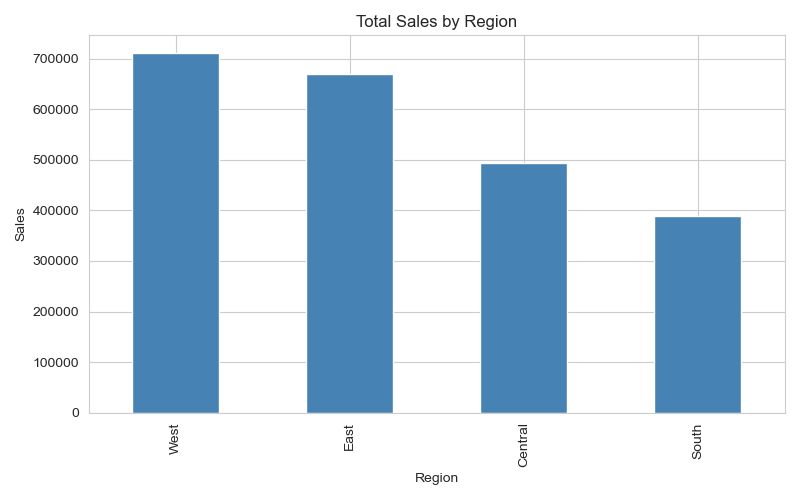

In [24]:
from IPython.display import Image
Image("sales_by_region.png")

In [25]:
top_products = df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10)
print("\nTop 10 Products by Sales:\n", top_products)


Top 10 Products by Sales:
 Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


In [26]:
subcat_sales = df.groupby("Sub-Category")["Sales"].sum().sort_values(ascending=False)
print("\nSales by Sub-Category:\n", subcat_sales.head(10))


Sales by Sub-Category:
 Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Name: Sales, dtype: float64


In [27]:
segment_summary = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)
print("\nSegment-wise Sales:\n", segment_summary)


Segment-wise Sales:
 Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


In [28]:
delivery_by_region = df.groupby("Region")["Delivery Time (Days)"].mean().round(2)
print("\nAvg Delivery Time by Region:\n", delivery_by_region)


Avg Delivery Time by Region:
 Region
Central    4.07
East       3.91
South      3.96
West       3.93
Name: Delivery Time (Days), dtype: float64


*****Export Cleaned Data*****

In [29]:
df.to_csv("train_Cleaned.csv", index=False)
print("\nCleaned data exported to train_Cleaned.csv")
print("Charts saved: monthly_sales_trend.png, sales_by_region.png")


Cleaned data exported to train_Cleaned.csv
Charts saved: monthly_sales_trend.png, sales_by_region.png
